# Análisis Exploratorio Bivariado


In [5]:
# Importación de librerías
#Hola
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import anderson, levene, chi2_contingency

# Carga del dataset y construcción del dataframe de trabajo
datos =pd.read_pickle("df_final.pkl")

df = datos.rename(columns={
    'KEY': 'clave',
    'FREQ':'frecuencia',
    'REF_AREA': 'pais_origen',
    'COUNT_AREA': 'pais_destino',
    'TYP_TRNSCTN': 'tipo_trx',
    'RL_TRNSCTN': 'tipo_psp',
    'FRD_TYP': 'tipo_fraude',
    'UNIT_MEASURE': 'unidad',   
    'TIME_PERIOD': 'anio',
    'OBS_VALUE': 'monto',
    'OBS_STATUS': 'tipo_monto',
    'DECIMALS':'decimales',
    'TITLE': 'descripcion',
    'UNIT_MULT':'multiplicador_unidad'
})

datos2 = df[[  
    'clave','frecuencia','pais_origen','pais_destino',
    'tipo_trx','tipo_psp','tipo_fraude',  'unidad',
    'anio','monto','tipo_monto','decimales',
    'descripcion','multiplicador_unidad',"monto_final"
]].copy()
datos2['anio'] = datos2['anio'].astype(str).str[:4]
datos2['tipo_fraude'] = (
    datos2['tipo_fraude']
    .str.replace('_Z', 'sin fraude', regex=False)
    .str.replace('F', 'con fraude', regex=False)
)
datos2.head()


,clave,frecuencia,pais_origen,pais_destino,tipo_trx,tipo_psp,tipo_fraude,unidad,anio,monto,tipo_monto,decimales,descripcion,multiplicador_unidad,monto_final
0,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2014,0.242,A,3,"Total payment transactions, incl. cash withdra...",6,0.242
1,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2015,0.268,A,3,"Total payment transactions, incl. cash withdra...",6,0.268
2,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2016,0.689,A,3,"Total payment transactions, incl. cash withdra...",6,0.689
3,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2017,0.632,A,3,"Total payment transactions, incl. cash withdra...",6,0.632
4,PAY.A.AT.BG.TOTL.1._Z.N.PN,A,AT,BG,TOTL,1,sin fraude,PN,2018,0.615,A,3,"Total payment transactions, incl. cash withdra...",6,0.615



## Análisis de la variable de respuesta frente a las variables numéricas

Realizaremos la comparación de la variable “tipo_fraude” correspondiente al tipo de fraude con la única variable númerica del dataset, la cual es “monto” correspondiente al valor de la transacción. En este caso, la variable de respuesta solo tiene dos opciones: “sin fraude” y “con fraude”, por tanto, se tomarán estos dos grupos y se analizará el valor de la transacción mediante el grafico de caja y bigotes bivariado para estas variables y se compararán las medias de estos dos grupos independientes, para ello se verificarán los supuestos de normalidad e igualdad de varianza para elegir la prueba correspondiente para al caso.

### Gráfico de caja y bigotes multiple

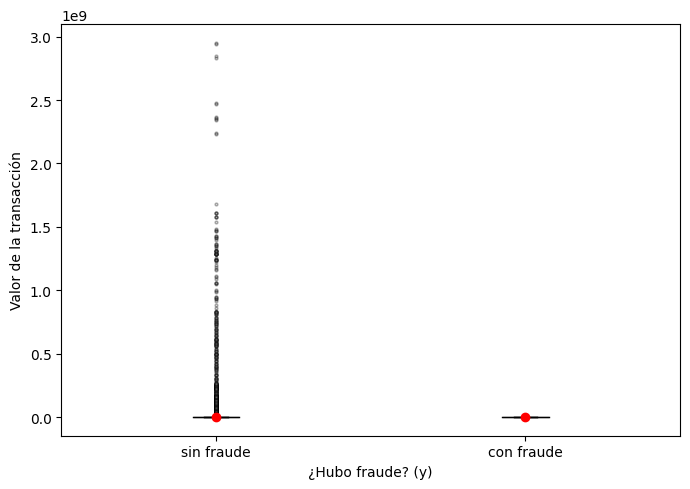

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

grupos = [datos2[datos2['tipo_fraude'] == g]['monto_final'].dropna() for g in datos2['tipo_fraude'].unique()]
etiquetas = list(datos2['tipo_fraude'].unique())

bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                boxprops=dict(facecolor='#1E90FF', alpha=0.6, color='black'),
                medianprops=dict(color='black'),
                flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3))
for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('¿Hubo fraude? (y)')
ax.set_ylabel('Valor de la transacción')
plt.tight_layout()
plt.show()

El gráfico muestra la distribución del valor de la transacciones según su respuesta a si hubo o no fraude. En el gráfico para las operaciones no fraudulentas se observa una alta dispersión y la presencia de numerosos valores extremos, alcanzando montos muy elevados, lo que indica gran variabilidad en transacciones legítimas. En contraste, las transacciones fraudulentas aparecen concentradas en valores bajos y con escasa variabilidad. Este patrón sugiere que el fraude se asocia principalmente a importes reducidos, mientras que los valores altos corresponden mayoritariamente a operaciones no fraudulentas.  


### Comparación de ambas muestras

Gracias a lo anterior, se realizará el análisis de la media de los valores de las transacciones en los grupos donde hubo y no hubo fraude. Para ello se procede realizar un análisis descriptivo básico entre los dos grupos.

In [7]:
def resumen(grupo):
    col = grupo['monto_final'].dropna()
    return pd.Series({
        'n':          len(grupo['monto_final']),
        'media':      col.mean(),
        'ds':         col.std(),
        'mediana':    col.median(),
        'minimo':     col.min(),
        'maximo':     col.max(),
        'Q1':         col.quantile(0.25),
        'Q3':         col.quantile(0.75),
        'IQR':        col.quantile(0.75) - col.quantile(0.25)
    })

tabla_grupos = datos2.groupby('tipo_fraude').apply(resumen).reset_index()

col_total = datos2['monto_final'].dropna()
tabla_total = pd.DataFrame([{
    'tipo_fraude': 'TOTAL',
    'n':          len(datos2['monto_final']),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

C:\Users\User\AppData\Local\Temp\ipykernel_18580\3109106573.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_grupos = datos2.groupby('tipo_fraude').apply(resumen).reset_index()


,tipo_fraude,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,con fraude,1944.0,47612.07,582476.32,0.33,0.0,1.554452e+07,0.01,27.23,27.22
1,sin fraude,660672.0,522158.74,19706399.88,1.37,-100.0,2.950583e+09,0.00,135.95,135.95
2,TOTAL,662616.0,520766.50,19677513.05,1.37,-100.0,2.950583e+09,0.00,135.16,135.16


La distribución del monto de las transacciones según el tipo de fraude muestra diferencias relevantes en las medidas de tendencia central. Se observa que la media es considerablemente mayor en el grupo sin fraude ($522,158) que en el grupo con fraude ($47,612); sin embargo, las medianas en ambos casos son cercanas a cero ($1.37 y $0.33 respectivamente), lo que indica una distribución fuertemente asimétrica hacia la derecha. Esta asimetría se confirma por las desviaciones estándar extremadamente elevadas y por la presencia de valores máximos muy grandes, así como por valores mínimos negativos que podrían corresponder a devoluciones o ajustes contables. El rango intercuartílico del grupo sin fraude (135.95) es notablemente superior al del grupo con fraude (27.22), sugiriendo que las transacciones fraudulentas tienden a concentrarse en montos más bajos y homogéneos. En este contexto, la mediana y el rango intercuartílico resultan medidas más representativas que la media, y podría considerarse una transformación logarítmica para estabilizar la varianza y mejorar el análisis; sin embargo, la presencia de valores negativos y ceros limita su viabilidad directa.   

### Prueba de normalidad

En esta ocasión se usará la prueba de Anderson-Darling porque las muestras son grandes y con cola hacia la derecha muy pronunciada.

In [8]:
grupo_F  = datos2[datos2['tipo_fraude'] == 'con fraude']['monto_final'].dropna()
grupo_Z  = datos2[datos2['tipo_fraude'] == 'sin fraude']['monto_final'].dropna()

res_F = anderson(grupo_F, dist='norm')
res_Z = anderson(grupo_Z, dist='norm')

print("Anderson-Darling: Grupo con fraude")
print(f"Estadístico: {res_F.statistic:.4f}")
print(f"Valor crítico al 5%: {res_F.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_F.statistic > res_F.critical_values[2] else 'No rechaza H0'}")

print("\nAnderson-Darling: Grupo sin fraude")
print(f"Estadístico: {res_Z.statistic:.4f}")
print(f"Valor crítico al 5%: {res_Z.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_Z.statistic > res_Z.critical_values[2] else 'No rechaza H0'}")

Anderson-Darling: Grupo con fraude
Estadístico: 698.8185
Valor crítico al 5%: 0.7850
Resultado: Rechaza H0 (no normal)

Anderson-Darling: Grupo sin fraude
Estadístico: 250256.0890
Valor crítico al 5%: 0.7870
Resultado: Rechaza H0 (no normal)


Con un nivel de confianza del 95% y dado que en ambas pruebas el p-valor es menor a 0.05, se puede concluir que ambas problaciones no siguen una distribución normal.  

### Test de Wilcoxon  

Se realizará el siguiente test de Wilcoxon porque es no paramétrico y responde a grupos que no siguen una distribución normal.  

In [9]:
from scipy.stats import mannwhitneyu

grupo_F = datos2.loc[datos2['tipo_fraude'] == 'con fraude', 'monto_final'].dropna()
grupo_Z = datos2.loc[datos2['tipo_fraude'] == 'sin fraude', 'monto_final'].dropna()

stat, p = mannwhitneyu(grupo_F, grupo_Z, alternative='two-sided')

print("Wilcoxon rank-sum (Mann-Whitney U)")
print(f"Estadístico U: {stat:.4f}")
print(f"p-valor: {p:.6f}")

Wilcoxon rank-sum (Mann-Whitney U)
Estadístico U: 599752901.5000
p-valor: 0.000000


La prueba de Wilcoxon arrojó un p-valor extremadamente pequeño menor a 0.05, lo que indica que se rechaza la hipótesis nula de igualdad en la distribución (o mediana) del monto de la transacción(monto) entre los grupos con fraude y sin fraude. En consecuencia, existe diferencia estadísticamente significativa de que los montos de las transacciones. Entonces, el valor de la transacción no se comporta de la misma manera en operaciones fraudulentas y no fraudulentas, lo que constituye un indicio de dependencia entre ambas variables.  

## Análisis de la variable de respuesta frente a las variables categóricas independientes.

### Variable clave

Para este analisis la variable clave (clave compuesta de la transacción) se excluye frente al tipo de fraude (tipo_fraude) porque presenta baja frecuencia por categoría, haciendo que sea poco interpretable. Además, clave corresponde a un código estructural compuesto que integra múltiples atributos técnicos, por lo que no representa una característica explicativa independiente con significado analítico propio.  

### Variable frecuencia

In [10]:
# Tabla de distribución de frecuencia según tipo_fraude
tabla_frecuencia = (
    datos2.groupby('tipo_fraude')['frecuencia']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'frecuencia': 'categoria'})
    .assign(variable='frecuencia')
)
tabla_frecuencia['porcentaje'] = tabla_frecuencia.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_frecuencia = tabla_frecuencia[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']]

**Gráfico de barras multiple**

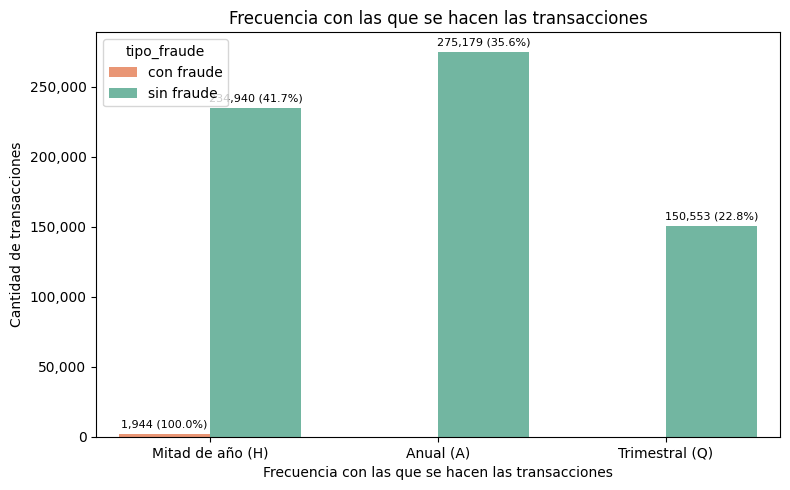

In [11]:
df_plot = tabla_frecuencia.copy()

df_plot['categoria'] = df_plot['categoria'].replace({
    'A': 'Anual (A)',
    'H': 'Mitad de año (H)',
    'Q': 'Trimestral (Q)'
})

df_plot['porcentaje'] = (
    df_plot.groupby('tipo_fraude')['n']
    .transform(lambda x: x / x.sum() * 100)
)

df_plot['label'] = df_plot.apply(
    lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)",
    axis=1
)

plt.figure(figsize=(8, 5))

palette1 = {
    'con fraude': '#fc8d62',
    'sin fraude': '#66c2a5'
}

ax = sns.barplot(
    x='categoria',
    y='n',
    hue='tipo_fraude',
    data=df_plot,
    palette=palette1,
    dodge=True
)

for container in ax.containers:
    fraude = container.get_label()
    porcentajes = df_plot.loc[df_plot['tipo_fraude'] == fraude, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)"
              for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Frecuencia con las que se hacen las transacciones')
plt.xlabel('Frecuencia con las que se hacen las transacciones')
plt.ylabel('Cantidad de transacciones')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

El gráfico muestra que la gran mayoría de las transacciones corresponden a la clase sin fraude, distribuyéndose principalmente en las categorías A (41.7%) y H (35.6%), mientras que Q representa una proporción menor. En contraste, los casos de fraude son extremadamente pocos y se concentran completamente en una sola categoría de frecuencia (H), lo que evidencia el fuerte desbalance de la variable respuesta. Esta diferencia sugiere que las transacciones realizadas con frecuencia a mitad de año son más propensas a que sean fraude y en otro caso es casi nula esta posibilidad.       

**Prueba de independencia**

In [12]:
tabla_frecuencia_chi = pd.crosstab(datos2['frecuencia'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_frecuencia_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 3504.0706
p-valor:        0.0000e+00
Grados de libertad: 2
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que la frecuencia con las que se realiza determinado pago está asociada con el tipo de fraude ($\chi^2_{(2)}=3504.1$, p-valor $<0.001$).  

### Variable  pais_origen  

Para el análisis de esta variable se realizará la tabla de contingencia con todas las categorías y el gráfico de barras múltiple solo con las 5 paises o zonas donde hubo más fraude. En este caso, no se hizo solamente el diagrama de barras porque hay muchas categorías diferentes.   

In [13]:
tabla_COUNTRY = (
    datos2.groupby('tipo_fraude')['pais_origen']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'pais_origen': 'categoria'})
    .assign(variable='pais_origen')
)
tabla_COUNTRY['porcentaje'] = tabla_COUNTRY.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_COUNTRY = tabla_COUNTRY[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

from IPython.display import display, HTML

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_COUNTRY.to_html(index=False) +
    '</div>'
))

tipo_fraude,variable,categoria,n,porcentaje
sin fraude,pais_origen,RO,28746,4.35
sin fraude,pais_origen,HU,28724,4.35
sin fraude,pais_origen,PL,28203,4.27
sin fraude,pais_origen,CZ,28063,4.25
sin fraude,pais_origen,NL,27204,4.12
sin fraude,pais_origen,PT,25600,3.87
sin fraude,pais_origen,LT,25520,3.86
sin fraude,pais_origen,DE,25149,3.81
sin fraude,pais_origen,FI,25092,3.80
sin fraude,pais_origen,LU,25086,3.80


La distribución del país de origen según la respuesta de si hubo fraude o no muestra diferencias relevantes en los patrones observados. En los casos donde se registró mayor proporción de fraude, el 5.86% corresponde a transacciones al area europea (U2), el 5.76% a estados miembros e instituciones de la Unión Europea (B0) y el 3.8% a España (ES). En contraste, en el grupo sin fraude, la mayor proporción (4.35%) corresponde al país de Romania(RO), mientras que el 4.34% a Hungria (HU) y el 4.26% a Polonia (PL) presentan valores ligeramente inferiores.   

**Gráfico de barras multiple**

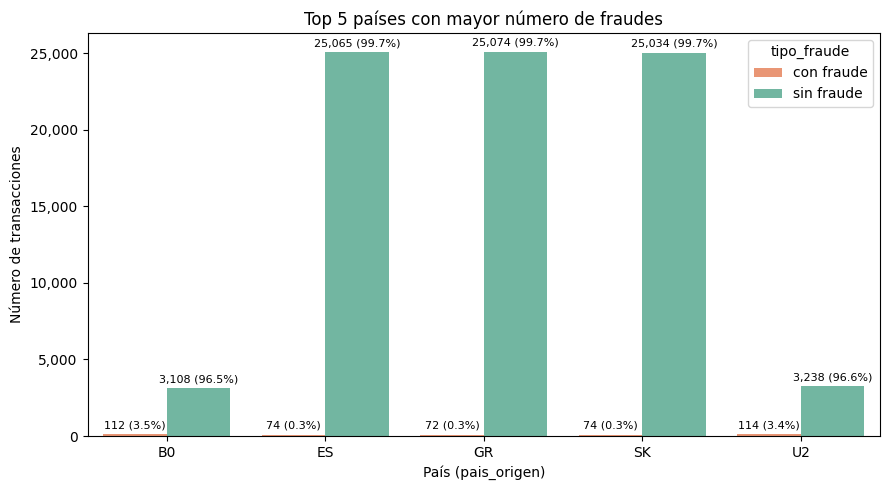

In [14]:
# Top 5 países con mayor número de fraudes
top5_paises = (
    datos2[datos2['tipo_fraude'] == 'con fraude']['pais_origen']
    .value_counts()
    .head(5)
    .index
)
df_plot = (
    datos2[datos2['pais_origen'].isin(top5_paises)]
    .groupby(['pais_origen', 'tipo_fraude'])
    .size()
    .reset_index(name='n')
)

df_plot['porcentaje'] = df_plot.groupby('pais_origen')['n'].transform(lambda x: x / x.sum() * 100)

df_plot['label'] = df_plot.apply(lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)", axis=1)
plt.figure(figsize=(9, 5))
ax = sns.barplot(x='pais_origen', y='n', hue='tipo_fraude', data=df_plot,
                 palette=palette1, dodge=True)
for container, (_, group) in zip(ax.containers, df_plot.groupby('tipo_fraude')):
    ax.bar_label(container, labels=group['label'], padding=3, fontsize=8)
plt.title('Top 5 países con mayor número de fraudes')
plt.xlabel('País (pais_origen)')
plt.ylabel('Número de transacciones')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

El gráfico muestra que, aunque estos cinco países concentran el mayor número absoluto de fraudes, la proporción de transacciones fraudulentas dentro de cada país sigue siendo muy baja en comparación con las no fraudulentas. En todos los casos, más del 96% de las transacciones corresponden a la categoría sin fraude, mientras que los fraudes representan entre aproximadamente 0.3% y 3.5% del total por país. Por tanto, esto sigue demostrando el fuerte desvalance de la variable de respuesta.   
Esta diferencia sugiere las zonas donde es más propenso a que las transacciones realizadas sean fraude son: en el pais de España (ES) y en las zonas del area Europea(U2) y Union Europea(B0), mientras que las transacciones de países como RO, HU y PL tienden a concentrarse en operaciones sin fraude, lo que podría ser relevante para estrategias de segmentación o análisis de comportamiento.  

**Prueba de independencia**

In [15]:
tabla_chi = pd.crosstab(datos2['pais_origen'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 2288.8730
p-valor:        0.0000e+00
Grados de libertad: 28
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que el país o zona de origen donde se hace determinada transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=2288.9$, p-valor $<0.001$).   

### Variable pais_destino  

Para el análisis de esta variable se realizará la tabla de contingencia con todas las categorías y el gráfico de barras múltiple solo con el país de destino donde hubo fraude. En este caso, no se hizo solamente el diagrama de barras porque hay muchas categorías diferentes.   

In [16]:
# Tabla de distribución de pais_destino según tipo_fraude
tabla_ORGANIZATION = (
    datos2.groupby('tipo_fraude')['pais_destino']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'pais_destino': 'categoria'})
    .assign(variable='pais_destino')
)
tabla_ORGANIZATION['porcentaje'] = tabla_ORGANIZATION.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_ORGANIZATION = tabla_ORGANIZATION[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_ORGANIZATION.to_html(index=False) +
    '</div>'
))

tipo_fraude,variable,categoria,n,porcentaje
sin fraude,pais_destino,W0,86789,13.14
sin fraude,pais_destino,W1,21755,3.29
sin fraude,pais_destino,W2,21507,3.26
sin fraude,pais_destino,G1,17392,2.63
sin fraude,pais_destino,SE,16057,2.43
sin fraude,pais_destino,DK,15769,2.39
sin fraude,pais_destino,BG,15488,2.34
sin fraude,pais_destino,GR,15440,2.34
sin fraude,pais_destino,SK,15437,2.34
sin fraude,pais_destino,SI,15437,2.34


La distribución de pais_destino según tipo_fraude muestra que las transacciones no fraudulentas se encuentran ampliamente distribuidas entre diversas áreas geográficas, destacándose entidades areas de referencia del mundo (W0) como la categoría con mayor participación (13.13%), seguida por el resto del mundo (W1) y hogares del mundo (W2), mientras que el resto de áreas presentan proporciones relativamente homogéneas alrededor del 2–3%.   
En contraste, los casos de fraude se concentran totalmente en la categoría W0, representando el 100% de los registros fraudulentos observados. Esta estructura evidencia una fuerte concentración geográfica del fraude frente a una distribución más diversificada de las transacciones legítimas, lo que sugiere que el riesgo no es uniforme entre áreas y que esta variable podría aportar capacidad explicativa en un modelo de clasificación.   

**Gráfico de cajas multiple**

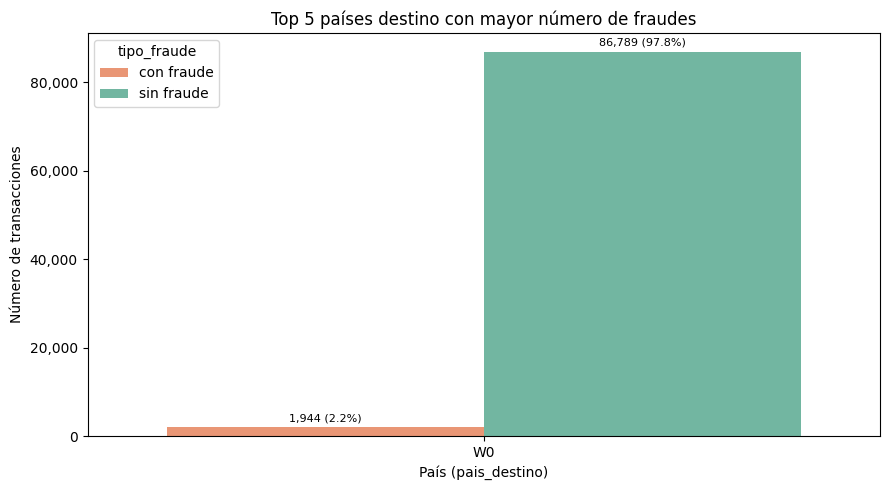

In [17]:
# Top 5 destinos con mayor número de fraudes
top5_dest = (
    datos2[datos2['tipo_fraude'] == 'con fraude']['pais_destino']
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    datos2[datos2['pais_destino'].isin(top5_dest)]
    .groupby(['pais_destino', 'tipo_fraude'])
    .size()
    .reset_index(name='n')
)
df_plot['porcentaje'] = df_plot.groupby('pais_destino')['n'].transform(lambda x: x / x.sum() * 100)
df_plot['label'] = df_plot.apply(lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)", axis=1)
plt.figure(figsize=(9, 5))
sns.barplot(x='pais_destino', y='n', hue='tipo_fraude', data=df_plot,
            palette=palette1, dodge=True)

ax = plt.gca()
for container, (_, group) in zip(ax.containers, df_plot.groupby('tipo_fraude')):
    ax.bar_label(container, labels=group['label'], padding=3, fontsize=8)


plt.title('Top 5 países destino con mayor número de fraudes')
plt.xlabel('País (pais_destino)')
plt.ylabel('Número de transacciones')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

El gráfico evidencia que el área W0 (Mundo, todas las entidades, incluido el área de referencia, incluido IO) concentra la totalidad de los fraudes observados (1,944 casos), aunque estos representan solo el 2.2% del total de transacciones en esa región, frente al 97.8% correspondiente a operaciones no fraudulentas. Esto indica que, si bien el fraude está focalizado geográficamente en W0, su ocurrencia sigue siendo baja en términos proporcionales, confirmando el fuerte desbalance de la variable.

**Prueba de independencia**

In [18]:

tabla_chi = pd.crosstab(datos2['pais_destino'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 12609.8660
p-valor:        0.0000e+00
Grados de libertad: 50
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que el país o zona de destino donde se hace determinada transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=12610$, p-valor $<0.001$).

### Variable tipo_trx  

**Gráfico de barras múltiple**  

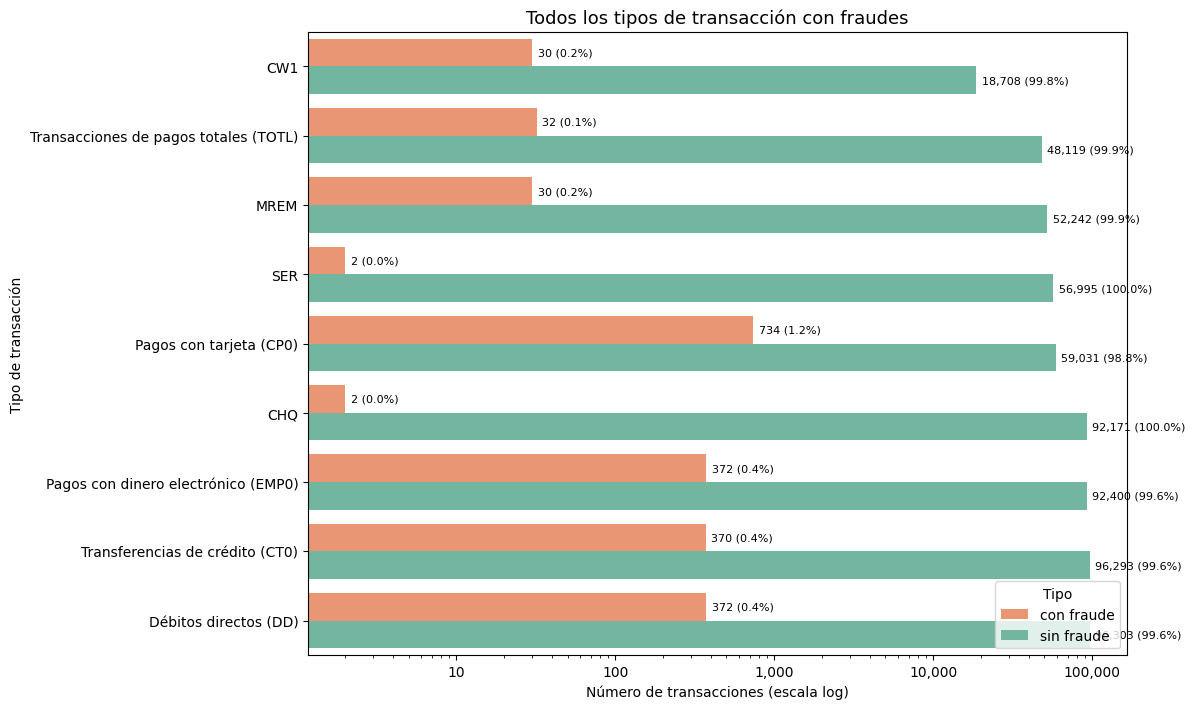

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

top_trx = (
    datos2[datos2['tipo_fraude'] == 'con fraude']['tipo_trx']
    .value_counts()
    .index
)

df_plot = (
    datos2[datos2['tipo_trx'].isin(top_trx)]
    .groupby(['tipo_trx', 'tipo_fraude'])
    .size()
    .reset_index(name='n')
)
df_plot['porcentaje'] = df_plot.groupby('tipo_trx')['n'].transform(lambda x: x / x.sum() * 100)
df_plot['label'] = df_plot.apply(lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)", axis=1)

label_map = {
    "CP0":  "Pagos con tarjeta (CP0)",
    "CT0":  "Transferencias de crédito (CT0)",
    "DD":   "Débitos directos (DD)",
    "EMP0": "Pagos con dinero electrónico (EMP0)",
    "TOTL": "Transacciones de pagos totales (TOTL)"
}
df_plot['tipo_trx_label'] = df_plot['tipo_trx'].map(label_map).fillna(df_plot['tipo_trx'])

orden = (
    df_plot.groupby('tipo_trx_label')['n']
    .sum()
    .sort_values()
    .index
    .tolist()
)

n_categorias = df_plot['tipo_trx_label'].nunique()

fig, ax = plt.subplots(figsize=(12, max(5, n_categorias * 0.8)))

sns.barplot(
    data      = df_plot,
    y         = 'tipo_trx_label',  
    x         = 'n',                
    hue       = 'tipo_fraude',
    palette   = palette1,
    dodge     = True,
    order     = orden,
    ax        = ax
)

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=8,
                 labels=[f"{int(v.get_width()):,} ({df_plot.loc[df_plot['n'] == int(v.get_width()), 'porcentaje'].values[0]:.1f}%)"
                         if int(v.get_width()) > 0 else ""
                         for v in container])

ax.set_title('Todos los tipos de transacción con fraudes', fontsize=13)
ax.set_ylabel('Tipo de transacción')
ax.set_xlabel('Número de transacciones (escala log)')
ax.set_xscale('log')                                               
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Tipo', loc='lower right')
plt.tight_layout()
plt.show()

En el gráfico se muestran que los tipos de transferencia con pagos con tarjeta (CPO), Transferencias de crédito (CTO), débitos directos (DD), Pagos con dinero electrónico (EMPO) y Transacciones de pago totales (TOTL) concentran el mayor número absoluto de fraudes, la proporción de transacciones fraudulentas dentro de cada tipo sigue siendo muy baja en comparación con las no fraudulentas. En todos los casos, más del 98% de las transacciones corresponden a la categoría sin fraude, mientras que los fraudes representan entre aproximadamente 0.1% y 1.2% del total por cada tipo de transacción. Por tanto, esto sigue demostrando el fuerte desvalance de la variable de respuesta y refleja que son excasos los casos de fraude frente a donde no hay.   

**Prueba de independencia**

In [20]:
tabla_chi = pd.crosstab(datos2['tipo_trx'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 2644.9980
p-valor:        0.0000e+00
Grados de libertad: 13
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que la clasificación de la transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=2645$, p-valor $<0.001$).   

### Variable tipo_psp

In [21]:

tabla_tipo_psp = (
    datos2.groupby('tipo_fraude')['tipo_psp']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'tipo_psp': 'categoria'})
    .assign(variable='tipo_psp')
)
tabla_tipo_psp['porcentaje'] = tabla_tipo_psp.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_tipo_psp = tabla_tipo_psp[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

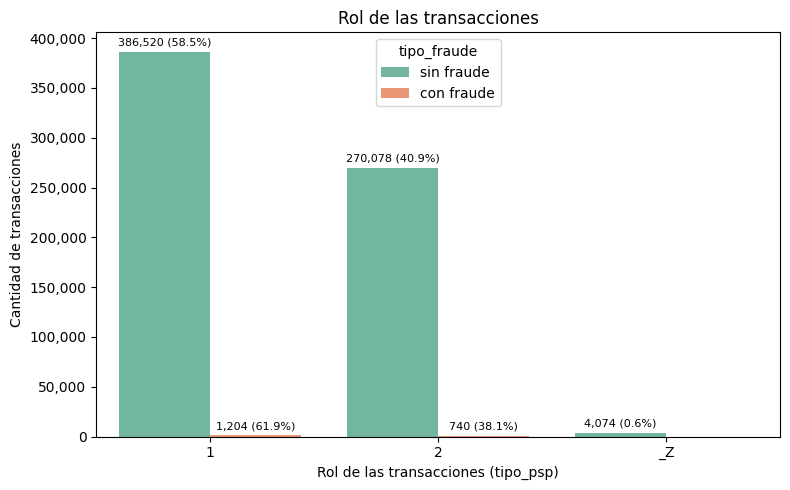

In [22]:

df_plot = tabla_tipo_psp.copy()

df_plot['label'] = df_plot.apply(
    lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)",
    axis=1
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(x='categoria',y='n',hue='tipo_fraude',data=df_plot,palette='Set2',dodge=True
)

for container in ax.containers:
    labels = [f"{int(v):,} ({p:.1f}%)"
              for v, p in zip(
                  container.datavalues,
                  df_plot.loc[
                      df_plot['tipo_fraude'] ==
                      container.get_label(),
                      'porcentaje'
                  ]
              )]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Rol de las transacciones')
plt.xlabel('Rol de las transacciones (tipo_psp)')
plt.ylabel('Cantidad de transacciones')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout()
plt.show()

La distribución de tipo_psp según la respuesta si hubo fraude o no, muestra diferencias relevantes en los patrones de respuesta. Entre las transacciones donde hubo fraude, el 61.93% corresponden a transacciones con rol tipo 1(PSP del pagador) y el 38.06% del tipo 2(PSP del beneficiario). En contraste, en el grupo donde no hubo fraude, la mayoría 58.5% fueron transacciones del rol tipo 1, mientras que el 40.87% al rol tipo 2 y 0.61% no aplica (_Z). Esta diferencia sugiere que las transacciones del rol tipo 1 son más propensas a que sean fraude, En general, las transacciones del tipo 1 son las que más se usan y son las que tienen mayor porcentaje de fraude respecto a las de tipo 2, lo que indica que tanto el volumen total como los eventos fraudulentos se concentran principalmente en el PSP del pagador.   

**Prueba de independencia**

In [23]:
# Prueba chi-cuadrado: tipo_psp vs tipo_fraude
tabla_chi = pd.crosstab(datos2['tipo_psp'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 19.6388
p-valor:        5.4386e-05
Grados de libertad: 2
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que la clasificación de la entidad procesa la transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=19.639$, p-valor $<0.001$).   

### Variable unidad  

**Gráfico de barras multiple**  

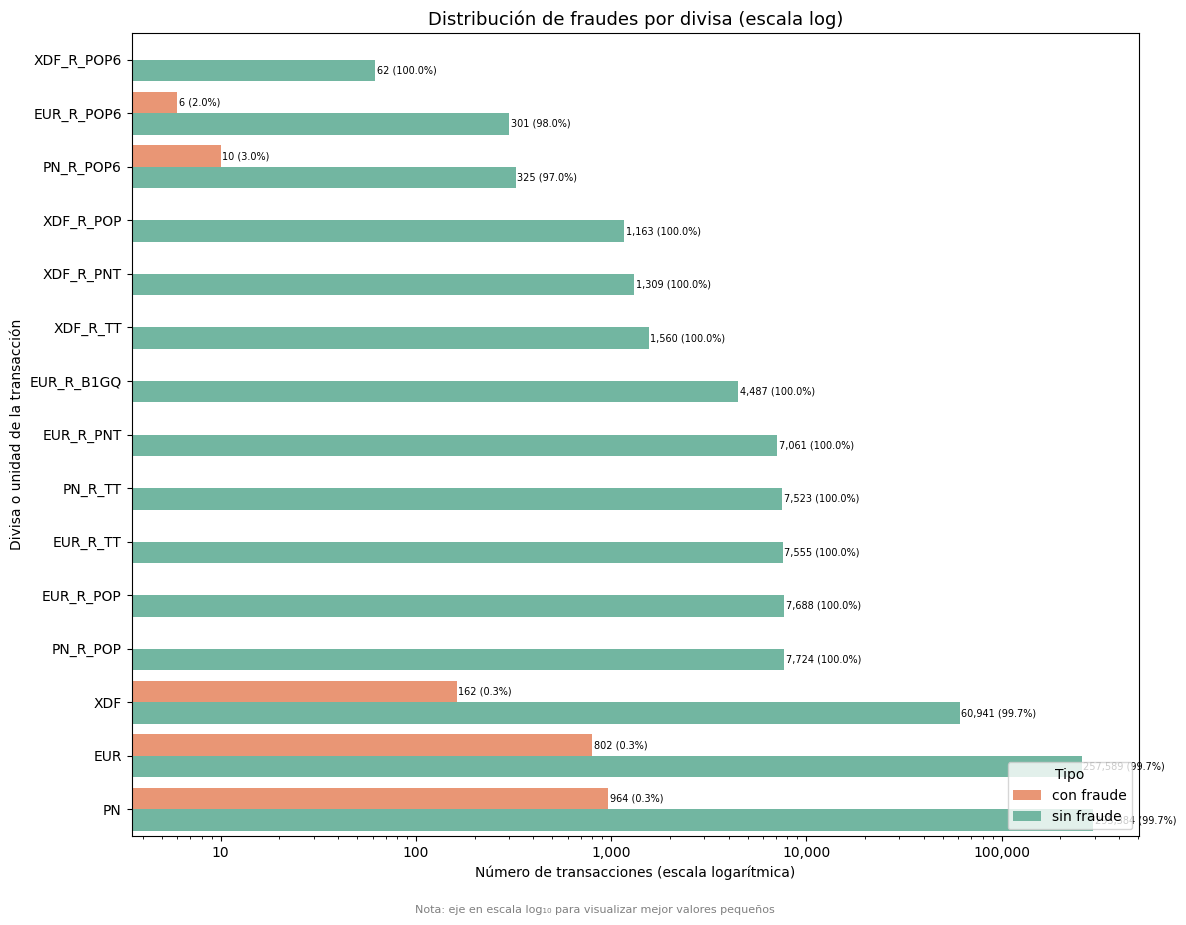

In [24]:
df_plot = (
    datos2
    .groupby(['unidad', 'tipo_fraude'])
    .size()
    .reset_index(name='n')
)
df_plot['porcentaje'] = df_plot.groupby('unidad')['n'].transform(lambda x: x / x.sum() * 100)

orden = (
    df_plot.groupby('unidad')['n']
    .sum()
    .sort_values()
    .index
    .tolist()
)

n_unidades = df_plot['unidad'].nunique()

fig, ax = plt.subplots(figsize=(12, max(5, n_unidades * 0.6)))

sns.barplot(
    data    = df_plot,
    y       = 'unidad',    
    x       = 'n',
    hue     = 'tipo_fraude',
    palette = palette1,
    dodge   = True,
    order   = orden,
    ax      = ax
)

for container in ax.containers:
    for bar in container:
        w = bar.get_width()
        if w > 0:
            match = df_plot[df_plot['n'] == int(w)]
            pct   = match['porcentaje'].values[0] if not match.empty else 0
            ax.text(
                w * 1.02,
                bar.get_y() + bar.get_height() / 2,
                f"{int(w):,} ({pct:.1f}%)",
                va='center', ha='left', fontsize=7
            )

ax.set_xscale('log')                                                   
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Distribución de fraudes por divisa (escala log)', fontsize=13)
ax.set_ylabel('Divisa o unidad de la transacción')
ax.set_xlabel('Número de transacciones (escala logarítmica)')
ax.legend(title='Tipo', loc='lower right')
fig.text(0.5, -0.02,
         'Nota: eje en escala log₁₀ para visualizar mejor valores pequeños',
         ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

La mayoría de las transacciones se registran en la categoría sin fraude, con proporciones cercanas al 99.7% en todas las unidades, mientras que las transacciones con fraude representa apenas alrededor del 0.3%. Aunque número puro (PN), Euro (EUR) y moneda nacional (XDF) concentran los mayores volúmenes, la incidencia relativa del fraude se mantiene estable entre monedas, lo que sugiere que el fraude se explica más por el volumen total de operaciones que por la unidad de transacción. Por tanto, las transacciones hechas con PN, EUR y XDF son más propensas a que tengan fraude, pero son proporcionalmente insignificantes frente a los casos donde no hubo en esas mismas categorías de monedas.    

**Prueba de independencia**

In [25]:

tabla_chi = pd.crosstab(datos2['unidad'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 262.2064
p-valor:        8.5336e-48
Grados de libertad: 14
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que la unidad o divisa involucrada en la transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=262.21$, p-valor $<0.001$).  

### Variable anio (año)

In [26]:

tabla_anio = (
    datos2.groupby('tipo_fraude')['anio']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'anio': 'categoria'})
    .assign(variable='anio')
)
tabla_anio['porcentaje'] = tabla_anio.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_anio = tabla_anio[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']]

tabla_anio.head(10)

,tipo_fraude,variable,categoria,n,porcentaje
0,con fraude,anio,2023,564,29.01
1,con fraude,anio,2024,564,29.01
2,con fraude,anio,2022,534,27.47
3,con fraude,anio,2025,282,14.51
4,sin fraude,anio,2023,143295,21.69
5,sin fraude,anio,2024,140071,21.20
6,sin fraude,anio,2022,136295,20.63
7,sin fraude,anio,2025,64070,9.70
8,sin fraude,anio,2018,17948,2.72
9,sin fraude,anio,2019,17948,2.72


Para este analisis la variable anio (año) se excluye frente a tipo_fraude porque presenta baja frecuencia por categoría, haciendo que sea poco interpretable. Además, anio corresponde a un código estructural compuesto que integra múltiples atributos técnicos, por lo que no representa una característica explicativa independiente con significado analítico propio. Cabe aclarar que aparecen pocas filas porque solo se mostraron las 40 primeras. Asimismo, no se realizará la prueba de independencia para esta variable con la de respuesta porque no es necesario para nuestro análisis y por la forma de esta variable. Lo único que se puede extraer de esta tabla es que en el año 2022, 2023 y 2024 fueron los años donde más fraude hubo, en el contexto de esta nueva era tecnológica producto del covid 19.  

### tipo_monto  

**Gráfico de barras multiple**  

In [27]:

tabla_tipo_monto = (
    datos2.groupby('tipo_fraude')['tipo_monto']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'tipo_monto': 'categoria'})
    .assign(variable='tipo_monto')
)
tabla_tipo_monto['porcentaje'] = tabla_tipo_monto.groupby('tipo_fraude')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_tipo_monto = tabla_tipo_monto[['tipo_fraude', 'variable', 'categoria', 'n', 'porcentaje']]


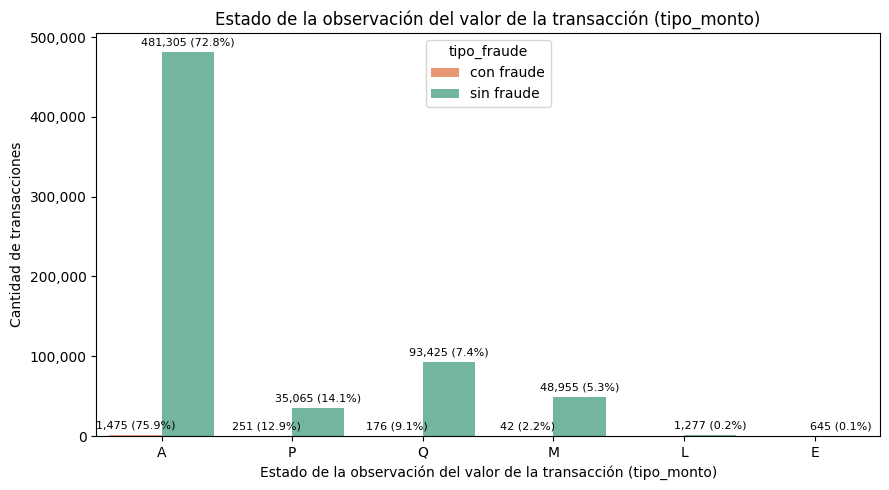

In [28]:

df_plot = tabla_tipo_monto.copy()
df_plot['label'] = df_plot.apply(
    lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)",
    axis=1
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x='categoria',
    y='n',
    hue='tipo_fraude',
    data=df_plot,
    palette=palette1,
    dodge=True
)

for container in ax.containers:
    fraude = container.get_label()
    porcentajes = df_plot.loc[df_plot['tipo_fraude'] == fraude, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)"
              for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Estado de la observación del valor de la transacción (tipo_monto)')
plt.xlabel('Estado de la observación del valor de la transacción (tipo_monto)')
plt.ylabel('Cantidad de transacciones')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

Para este análisis, en la variable tipo_monto no se excluirán las categorías L (valor faltante; los datos existen pero no fueron recopilados), M (valor faltante; los datos no pueden existir) y Q (valor faltante; suprimido), porque, a pesar de que corresponden a valores faltantes, la variable de respuesta de la investigación es si hubo o no fraude. Por tanto, se busca identificar este aspecto antes que determinar de cuánto fue el fraude.  
En este caso, la distribución del estado de la observación según tipo_fraude muestra diferencias relevantes en los patrones observados. Entre las transacciones con fraude (F), la categoría A (valor normal) es claramente mayoritaria (75.87%), seguida por P (valor provisional) (12.91%) y Q (valor faltante; reprimido) (9.05%), mientras que M (valor faltante; los datos no pueden existir) presenta una participación reducida (2.16%).  
En contraste, en las transacciones sin fraude, aunque A también predomina (72.85%), se aprecia una mayor presencia relativa de Q (14.14%), M (7.41%) y P (5.30%), además de categorías marginales como E y L. Esta diferencia sugiere que los eventos de fraude tienden a concentrarse principalmente en el estado A, mientras que las operaciones legítimas presentan una distribución más diversificada, lo que podría ser relevante para el análisis de riesgo y la identificación de patrones de comportamiento. 

El gráfico de tipo_monto indica que la categoría A(valor normal) concentra la mayor parte de las transacciones (≈72.9%), seguida por Q(valor faltante; suprimido) con un 14.1%, M(valor faltante; los datos no pueden existir)  con 7.4% y P(valor prosivional) con 5.3%, mientras que E(valor estimado) y L(Valor faltante; los datos existen pero no fueron recopilados.) son marginales. En los casos de fraude (F) se mantiene la misma estructura general, con predominio de A, aunque con una participación relativamente mayor en P y Q frente al conjunto total. Esto sugiere que, si bien la distribución global está dominada por A, ciertas categorías como P y Q adquieren mayor relevancia relativa dentro de las operaciones fraudulentas.   

**Prueba de independencia**

In [29]:

tabla_chi = pd.crosstab(datos2['tipo_monto'], datos2['tipo_fraude'])
chi2, p, dof, expected = chi2_contingency(tabla_chi)


print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 326.1143
p-valor:        2.4212e-68
Grados de libertad: 5
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado nos indica que el tipo de monto de la transacción está asociada con el tipo de fraude ($\chi^2_{(2)}=326.11$, p-valor $<0.001$).  

### Variable DESCRIPTION

Para este analisis la variable descripcionse excluye frente a tipo_fraude porque corresponde a un código estructural compuesto que integra múltiples atributos técnicos, en esta variable se describe la transacción y dice si hubo fraude, el tipo de transacción y si fue enviada, por lo cual, se tiene esta informacion de otras variables ya analizadas previamente. Asimismo, no se realizará la prueba de independencia para esta variable con la de respuesta porque no es necesario para nuestro análisis y por la forma de esta variable.  

## Conclusión

El anterior análisis permitió conocer a profundidas caracteristicas generales del dataset escogido tales como número de observaciones y variables estudiandes. De la misma manera, permitió estudiar el posible impacto en este proyecto de cada una de las columnas listadas, pues, fuera por falta de documentación en la funete original o duplicación de información, no todas eran aptas de ser incluidas. En un reconocimiento inicial se vio que la variable objetivo **tipo_fraude**, se encuentra desbalanceada a favor de observaciones que no presentaron fraude, de la misma forma, se pudo conocer a grandes rasgos, la distribución particular de las variables presentes en los datos como los países origen, destino, año de origen, monto o conteo, tipo de unidad, tipo de multiplicador, tipo de psp, descripción, por mencionar algunas. 

Al compara los tipos de fraude con las diferentes variables se encontró que existe dependencia en la mayoría de casos. Aún así, es importante resaltar que los fraudes se concentran en categorías muy particulares, por ejemplo, en solo una de las categorías de la variable frecuencia se encontraron casos de fraude. Por otro lado, en la variable monto se encontró diferencias significativas entre el grupo en el que se identifica fraude y el grupo en el que no. Los montos suelen ser menores en las transacciones fraudulentas que en las que no lo son. 

## Referencias
[European Central Bank. Payments transactions (Key indicators) - PAY ](https://data.ecb.europa.eu/data/datasets/PAY/data-information?dataset%5B0%5D=Payments%20transactions%20%28Key%20indicators%29%20%28PAY%29&advFilterDataset%5B0%5D=Payments%20transactions%20%28Key%20indicators%29%20%28PAY%29&layerType=AL&showDatasetModal=false)